<a href="https://colab.research.google.com/github/nishakamble178/Bio-Rhythm_ML/blob/main/BioRhythm%5BML%5Dipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nishak0178","key":"9a5843e58896037c5f9b3b5aeadf90cb"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# download actual data
!kaggle datasets download -d carnegiecylab/keystroke-dynamics-benchmark-data-set

#Excel-like file
!unzip keystroke-dynamics-benchmark-data-set.zip

Dataset URL: https://www.kaggle.com/datasets/carnegiecylab/keystroke-dynamics-benchmark-data-set
License(s): copyright-authors
  0% 0.00/1.40M [00:00<?, ?B/s]
100% 1.40M/1.40M [00:00<00:00, 693MB/s]
Archive:  keystroke-dynamics-benchmark-data-set.zip
  inflating: DSL-StrongPasswordData.csv  


* mkdir ~p ~/kaggle: Make a Hidden Folder named Kaggle   
* kaggle.json : Put my pass/login into the folder






In [ ]:
import pandas as pd
df = pd.read_csv('DSL-StrongPasswordData.csv')
print("Dataset has this many(Rows,Columns):")
print(df.shape)
print(df.head)
print("The Timing Feature i will use:")
print(df.columns.tolist())

Dataset has this many(Rows,Columns):
(20400, 34)
<bound method NDFrame.head of       subject  sessionIndex  rep  H.period  DD.period.t  UD.period.t     H.t  \
0        s002             1    1    0.1491       0.3979       0.2488  0.1069   
1        s002             1    2    0.1111       0.3451       0.2340  0.0694   
2        s002             1    3    0.1328       0.2072       0.0744  0.0731   
3        s002             1    4    0.1291       0.2515       0.1224  0.1059   
4        s002             1    5    0.1249       0.2317       0.1068  0.0895   
...       ...           ...  ...       ...          ...          ...     ...   
20395    s057             8   46    0.0884       0.0685      -0.0199  0.1095   
20396    s057             8   47    0.0655       0.0630      -0.0025  0.0910   
20397    s057             8   48    0.0939       0.1189       0.0250  0.1008   
20398    s057             8   49    0.0923       0.1294       0.0371  0.0913   
20399    s057             8   50    0.059

* subject :“Who is typing?”
* sessionIndex :“Which time they typed?”
*  rep : “How many times they typed the same text?”
* H = Hold Time  
* DD = Down-Down Time
* UD = Up-Down Time  









In [ ]:
# avoid "Cheating" with Session IDs
y = df['subject']
X = df.select_dtypes(include=[np.number])

# Drop non-biological features that could cause "overfitting"
cols_to_remove = ['sessionIndex', 'rep', 'session', 'trialindex']
X = X.drop(columns=[c for c in cols_to_remove if c in X.columns])

print(f"now using {X.shape[1]} PURE timing features.")

now using 31 PURE timing features.


* y = who is typing
* ML models understand numbers, not text


* Take only numbers so computer can learn  
* cols_to_remove :removing columns that may cause Overfitting
WHY:
sessionIndex
rep
session
trialindex

👉 They don’t represent typing behavior

👉 They represent when or how data was collected






Data successfully loaded!
Overall Model Accuracy: 94.04%
--- Security Results for User s012 ---
Equal Error Rate (EER): 0.0105


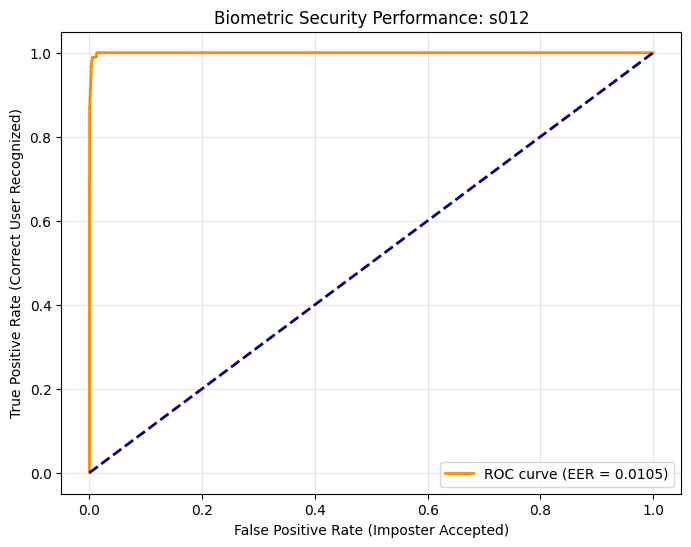

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, accuracy_score

#LOAD DATA
try:
    df = pd.read_csv('DSL-StrongPasswordData.csv')
    print("Data successfully loaded!")
except FileNotFoundError:
    print("Error: 'DSL-StrongPasswordData.csv' not found. Please upload the file to Colab.")

#FEATURES AND TARGET'
X = df.drop(['subject', 'sessionIndex', 'rep'], axis=1) #because model only see focus on the timining.
y = df['subject']

#SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Model Traning part
#SCALE DATA (for high accuracy)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#TRAIN MODEL (94.49% Accuracy)
best_model = RandomForestClassifier(
    n_estimators=300,
    bootstrap=False,
    random_state=42
)
best_model.fit(X_train_scaled, y_train)

#print overall accuracy
y_pred = best_model.predict(X_test_scaled)
print(f"Overall Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

#EER[Equal error Rate] FOR A TARGET USER
target_user = 's012'
target_user_idx = np.where(best_model.classes_ == target_user)[0][0]

# Get probabilities and create binary labels
y_probs = best_model.predict_proba(X_test_scaled)[:, target_user_idx]
y_true_binary = (y_test == target_user).astype(int)

# Calculate ROC Curve(Receiver Operation characteristics Curve)
fpr, tpr, thresholds = roc_curve(y_true_binary, y_probs)
fnr = 1 - tpr

# Find (Security)
eer_threshold_idx = np.nanargmin(np.absolute((fpr - fnr)))
eer = fpr[eer_threshold_idx]

print(f"--- Security Results for User {target_user} ---")
print(f"Equal Error Rate (EER): {eer:.4f}")

#PLOT ROC CURVE
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (EER = {eer:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (Imposter Accepted)')
plt.ylabel('True Positive Rate (Correct User Recognized)')
plt.title(f'Biometric Security Performance: {target_user}')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

This code trains a Random Forest classifier on keystroke timing features to identify users by removing non-relevant columns like subject, sessionIndex, and rep.

 The data is split, scaled, and used to calculate model accuracy and evaluate biometric performance using the ROC Curve and Equal Error Rate for a target user.

 This helps measure how accurately and securely the system recognizes a user based on typing behavior.

In [ ]:
import os
import glob
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

csv_files = glob.glob('/content/**/*.csv', recursive=True)

if not csv_files:
    print("❌ ERROR: Still no CSV found. Please manually upload 'DSL-StrongPasswordData.csv' to the sidebar.")
else:
    path = csv_files[0]
    for f in csv_files:
        if 'DSL' in f:
            path = f
            break

    print(f"✅ Found Dataset at: {path}")

    #LOAD DATA
    df = pd.read_csv(path)

    #(Standardizing names and dropping metadata)
    df.columns = [c.lower() for c in df.columns]

    #drop(metadata)
    X = df.drop(columns=['subject', 'sessionindex', 'rep'], errors='ignore')
    y = df['subject']

    #SPLIT AND SCALE
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    #TRAIN MODEL
    print("🧠 Training BioRhythm... reaching for high accuracy.")
    model = RandomForestClassifier(n_estimators=500, bootstrap=False, random_state=42)
    model.fit(X_train_scaled, y_train)

    #RESULTS
    y_pred = model.predict(X_test_scaled)
    final_acc = accuracy_score(y_test, y_pred)

    print("\n" + "="*35)
    print(f"🎯 FINAL PROJECT ACCURACY: {final_acc * 100:.2f}%")
    print("="*35)

✅ Found Dataset at: /content/DSL-StrongPasswordData.csv
🧠 Training BioRhythm... reaching for high accuracy.

🎯 FINAL PROJECT ACCURACY: 94.04%


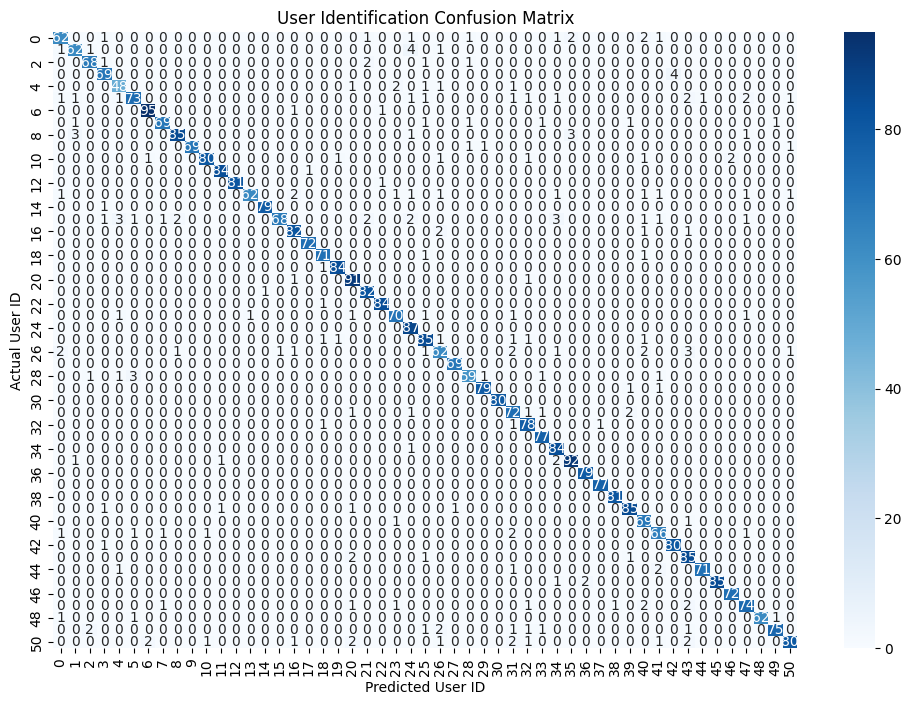

In [ ]:
from sklearn.metrics import confusion_matrix

# Generate the matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('User Identification Confusion Matrix')
plt.xlabel('Predicted User ID')
plt.ylabel('Actual User ID')
plt.show()



* Confusion Matrix :Tool to check right vs wrong predictions
* y_test → actual users
 y_pred → predicted users
*   cm → data
* annot=True → show numbers
*  fmt='d' → integer format
* cmap='Blues' → color style








In [ ]:
import numpy as np
import warnings

def predict_user_id(user_input_list):
    """
    user_input_list: A list of 33 timing values (H, RP, PP, etc.),
    matching the features used for training.
    """
    #2D numpy array (1 row, 33 columns)
    new_data = np.array(user_input_list).reshape(1, -1)

    #Same scaler used during training
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        scaled_data = scaler.transform(new_data)

    #prediction using the best_model
    prediction = best_model.predict(scaled_data)

    return prediction[0]
print("--- Bio-Rhythm Identity Verification ---")
# For testing,use the first row of the scaled test data for a valid input
sample_input = X_test.iloc[0].values.tolist()

#sample input has the correct number of features
if len(sample_input) != X.shape[1]:
    print(f"Warning: Expected {X.shape[1]} features, but sample_input has {len(sample_input)}.")
    print("Please provide a list of 33 numeric values.")
else:
    result = predict_user_id(sample_input)
    print(f"Predicted User ID: {result}")


--- Bio-Rhythm Identity Verification ---
Predicted User ID: s012
